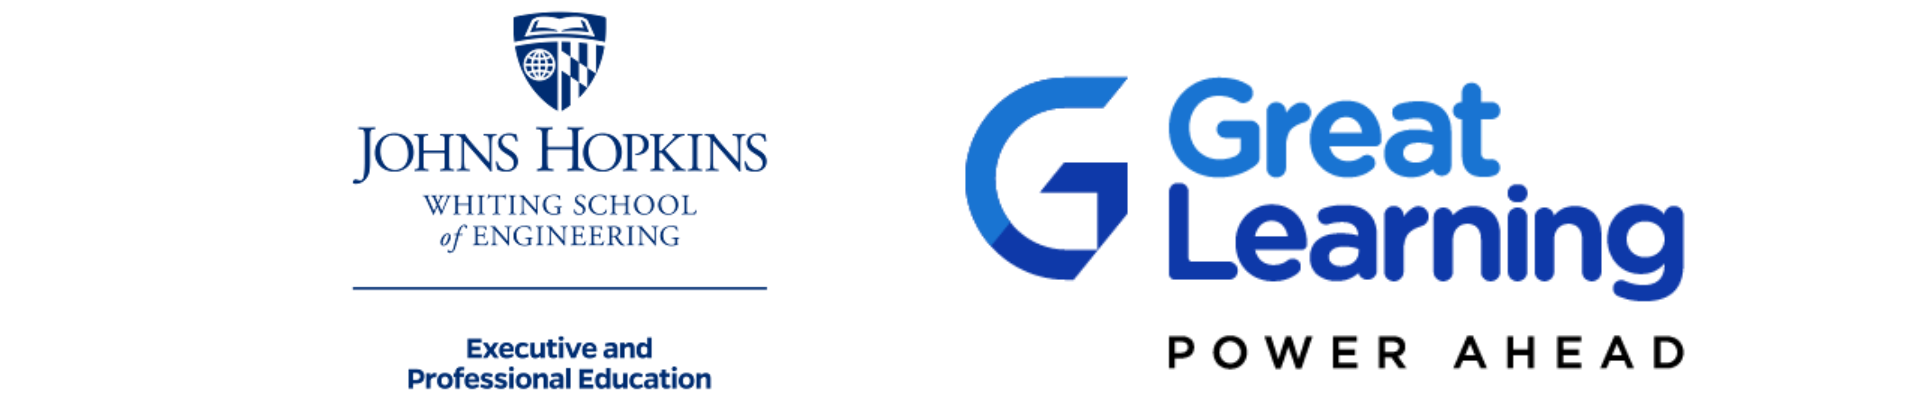

# **Project 1 - DualLens Analytics**

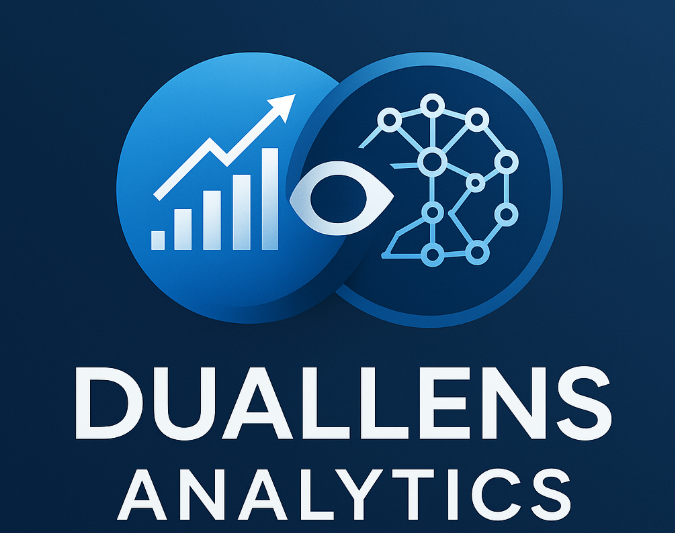

### **Background Story**
In the rapidly evolving world of finance and technology, investors are constantly seeking ways to make smarter decisions by combining traditional financial analysis with emerging technological insights. While stock market trends provide a numerical perspective on growth, an organization’s initiatives in cutting-edge fields like Artificial Intelligence (AI) reveal its future readiness and innovation potential.
However, analyzing both dimensions - quantitative financial performance and qualitative AI initiatives - requires sifting through multiple, diverse data sources: stock data from platforms like Yahoo Finance, reports in PDFs, and contextual reasoning using Large Language Models (LLMs).

This is where **DualLens Analytics** comes in. By applying a dual-lens approach, the project leverages **Retrieval-Augmented Generation (RAG)** to merge **financial growth data** with **strategic insights from organizational reports**. Stock data provides evidence of stability and momentum, while AI initiative documents reveal forward-looking innovation. Together, they form a richer, more holistic picture of organizational potential.

With DualLens Analytics, investors no longer need to choose between numbers and narratives—they gain a unified, AI-driven perspective that ranks organizations by both financial strength and innovation readiness, enabling smarter, future-focused investment strategies.

### **Problem Statement**

Traditional investment analysis often focuses on financial metrics alone (e.g., stock growth, revenue, market cap), missing the qualitative dimension of how prepared a company is for the future.
On the other hand, qualitative documents like strategy PDFs contain valuable insights about innovation and AI initiatives, but they are difficult to structure, query, and integrate with numeric financial data.

This leads to three core challenges:

1. **Fragmented Data Sources:** Financial data (stock prices) and strategic insights (PDFs) exist in silos.

2. **Limited Analytical Scope:** Manual analysis of growth trends and PDF reports is time-consuming and error-prone.

3. **Decisional Blind Spots:** Without integrating both quantitative (growth trends) and qualitative (AI initiatives) signals, investors may miss out on high-potential organizations.

### **Solution Approach**
To address this challenge, we set out to build a **Retrieval-Augmented Generation (RAG)** powered system that blends financial trends with AI-related strategic insights, helping investors rank organizations based on growth trajectory and innovation capacity.

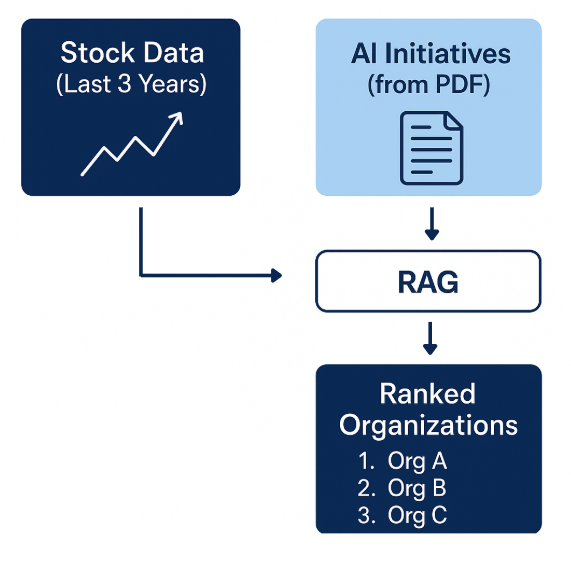

---

### <font color="red"> **# Important Points To Note** </font>

1. For LLM please use **`"gpt-4o-mini"`** model.
2.  You need to look for **`"--- --- ---"`** and add your code over there, this is a placeholder.
3. For project submission, please provide the project in **HTML format.**  Refer to the **"Guidelines: Converting IPYNB to HTML Files.pdf"** for instructions.
4. Ensure all **outputs are clearly visible,** and enclose prompts in triple quotes **`"""`** so they remain fully visible when the notebook is converted from IPYNB to HTML.

---

#**Setting up Installations and Imports**

In [1]:
# @title Run this cell => Restart the session => Start executing the below cells **(DO NOT EXECUTE THIS CELL AGAIN)**

!pip install langchain==0.3.25 \
                langchain-core==0.3.65 \
                langchain-openai==0.3.24 \
                chromadb==1.3.4 \
                langchain-community==0.3.20 \
                pypdf==5.4.0

In [2]:
!pip install yfinance

In [3]:
import yfinance as yf              # Used for gathering stock prices
import matplotlib.pyplot as plt    # Used for Data Visualization / Plots / Graphs
import pandas as pd                # Helpful for working with tabular data like DataFrames
import os                          # Interacting with the operating system

from langchain.text_splitter import RecursiveCharacterTextSplitter      #  Helpful in splitting the PDF into smaller chunks

from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader     # Loading a PDF
from langchain_community.vectorstores import Chroma    # Vector DataBase

#**1. Organization Selection**

Selecting the below five organizations as the analysis pool.



In [4]:
companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

#**2. Setting up LLM - 1 Marks**

- The `config.json` file should contain **API_KEY** and **API BASE URL** provided by OpenAI.
- You need to insert your actual API keys and endpoint URL obtained from your Olympus account. Refer to the **OpenAI Access Token documentation** for more information on how to generate and manage your API keys.
- This code reads the `config.json` file and extracts the API details.
  - The `API_KEY` is a **unique secret key** that authorizes your requests to OpenAI's API.
  - The `OPENAI_API_BASE` is the **API BASE URL** where the model will process your requests.

**What To Do?**
- Use the sample `config.json` file provided.
- Add their **OpenAI API Key** and **Base URL** to the file.
- The `config.json` should look like this:

  ```
  {
        "API_KEY": "your_openai_api_key_here",
        "OPENAI_API_BASE": "https://your_openai_api_base/v1"
      }
  ```

In [5]:
#Loading the `config.json` file
import json
import os

# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url

In [6]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",          # "gpt-4o-mini" to be used as an LLM
    temperature=0,                # Set the temprature to 0
    max_tokens=5000,              # Set the max_tokens = 5000, so that the long response will not be clipped off
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

#**3. Visualization and Insight Extraction - 5 Marks**

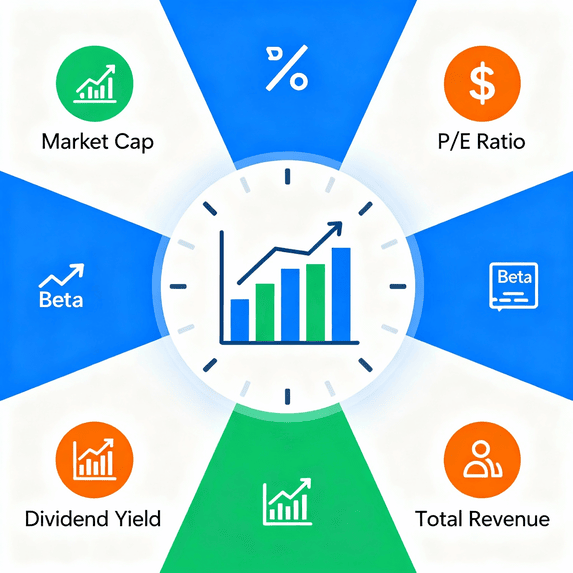

Gather stock data for the selected organization from the past three years using the YFinance library, and visualize this data for enhanced analysis.

> <font color="red" size=5>**Your Task**</font>
1. Loop through each company to retrieve stock data of the last three years using the YFinance library.
2. Plot the closing prices for each company.

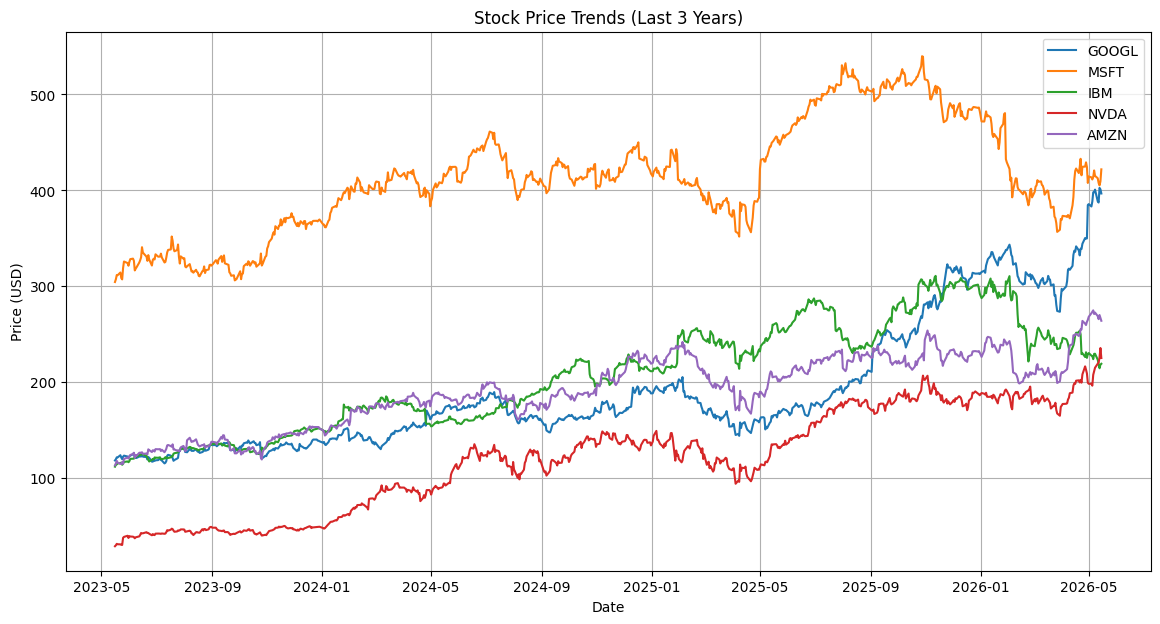

In [7]:
plt.figure(figsize=(14,7))

# Loop through each company and plot closing prices
for symbol in companies:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="3y")

    # Plot closing price
    plt.plot(data.index, data['Close'], label=symbol)

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.savefig("Stock_Price_Trends_3Y.png")
plt.show()

#### **Financial Metrics**

1. **Market Cap:** Total market value of a company’s outstanding shares.
2. **P/E Ratio:** Shows how much investors are willing to pay per dollar of earnings.
3. **Dividend Yield:** Annual dividend income as a percentage of the stock price.
4. **Beta**: Measures a stock’s volatility relative to the overall market.
5. **Total Revenue:** The total income a company generates from its business operations.





> <font color="red" size=5>**Your Task**</font>

1. Loop through all the companies to fetch data based on the specified financial metrics.
2. Create a DataFrame (DF) from the collected data.
3. Visualize and compare each financial metric across all companies.
4. For example, visualize and compare the market capitalization for each company.


*Tip: Check `ticker.info` for the available financial metrics*

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]
metrics_list = {}

# Fetching the financial metrics
for symbol in companies:                          # Loop through all the companies
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {                              # Define the dictionary of all the Finanical Metrics
        "Market Cap": info.get("marketCap", 0),
        "P/E Ratio": info.get("trailingPE", 0),
        "Dividend Yield": info.get("dividendYield", 0),
        "Beta": info.get("beta", 0),
        "Total Revenue": info.get("totalRevenue", 0)
    }

In [9]:
# Convert to DataFrame
df = pd.DataFrame(metrics_list).T

# Converting large numbers to billions for readability by divinding the whole column by 1e9
df["Market Cap"] = df["Market Cap"] / 1e9
df["Total Revenue"] = df["Total Revenue"] / 1e9
df["Dividend Yield"] = df["Dividend Yield"] * 100  # Convert to percentage

df   # Printing the df

,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,4807.165739,30.311687,22.0,1.267,422.498009
MSFT,3134.205460,25.129244,86.0,1.093,318.272995
IBM,206.116848,19.424269,308.0,0.581,68.910998
NVDA,5457.368842,46.077713,2.0,2.244,215.938007
AMZN,2841.383010,31.633533,0.0,1.468,742.775980


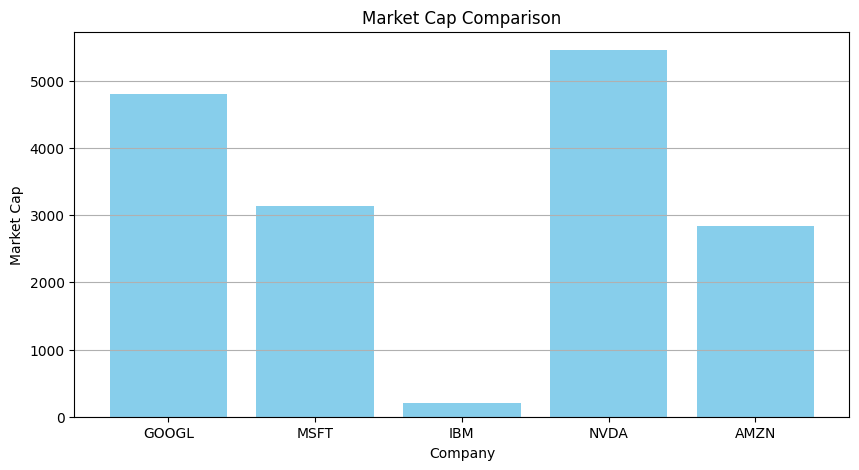

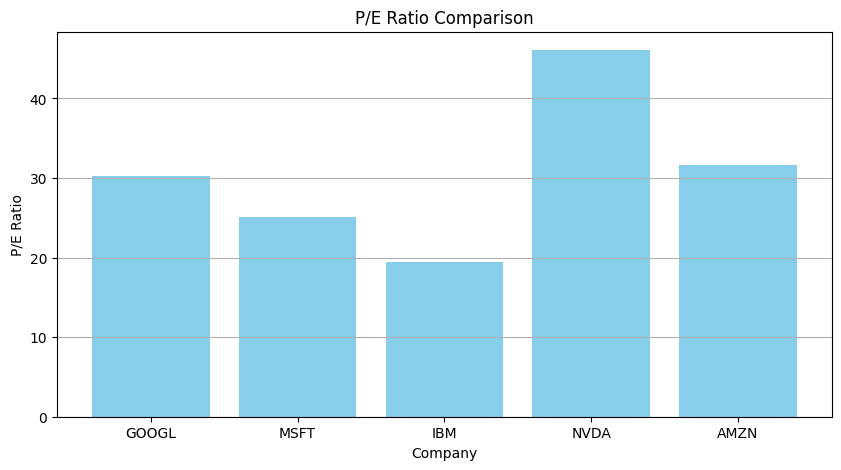

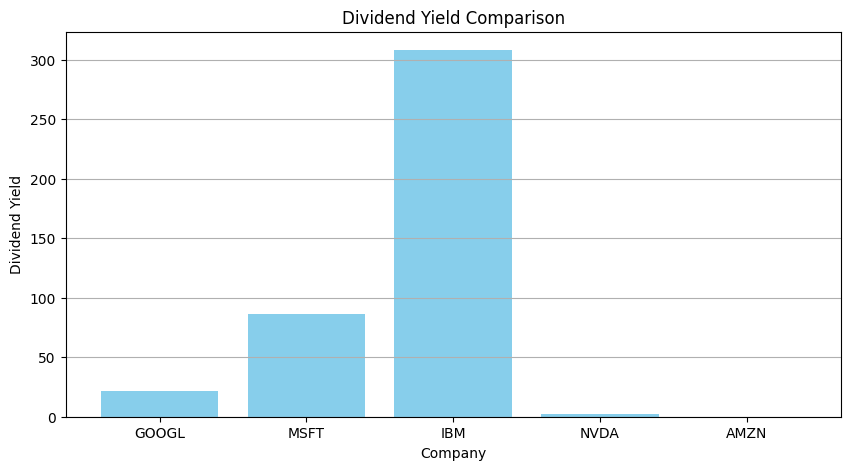

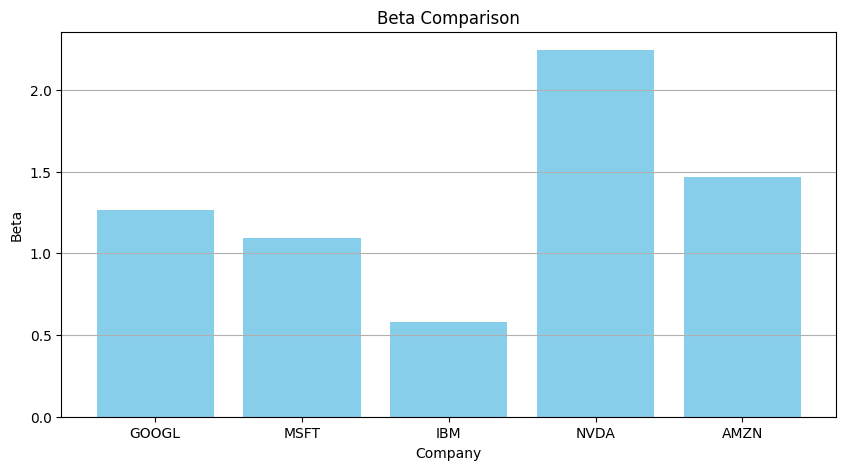

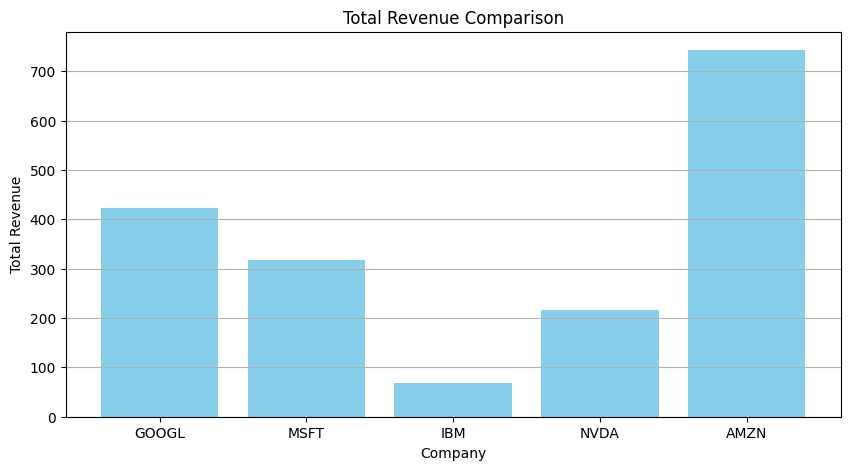

In [10]:
# Plot each metric as a separate bar graph
metrics_to_plot = ["Market Cap","P/E Ratio","Dividend Yield","Beta","Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,5))
    plt.bar(df.index, df[metric], color='skyblue')
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y')
    plt.show()


#**4. RAG-Driven Analysis - 7 Marks**

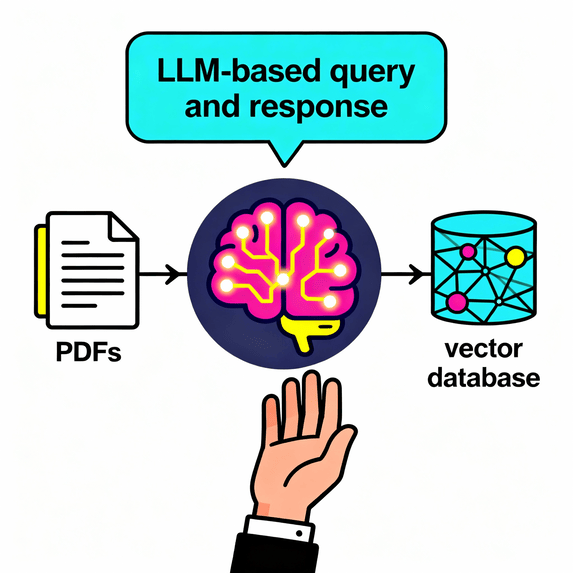

Performing the RAG-Driven Analysis on the AI Initiatives of the companies  

> <font color="red" size=5>**Your Task**</font>

1. Extract all PDF files from the provided ZIP file.
2. Read the content from each PDF file.
3. Split the content into manageable chunks.
4. Store the chunks in a vector database using embedding functions.
5. Implement a query mechanism on the vector database to retrieve results based on user queries regarding AI initiatives.
6. Evaluate the LLM generated response using LLM-as-Judge

### **A. Loading Company AI Initiative Documents (PDFs) -  1 mark**

In [11]:
# Unzipping the AI Initiatives Documents
import zipfile
with zipfile.ZipFile("./content/Companies-AI-Initiatives.zip", 'r') as zip_ref:
  zip_ref.extractall("./content/")         # Storing all the unzipped contents in this location

In [12]:
# Path of all AI Initiative Documents
ai_initiative_pdf_paths = [f"./content/Companies-AI-Initiatives/{file}" for file in os.listdir("./content/Companies-AI-Initiatives")]
ai_initiative_pdf_paths

['./content/Companies-AI-Initiatives/IBM.pdf',
 './content/Companies-AI-Initiatives/GOOGL.pdf',
 './content/Companies-AI-Initiatives/AMZN.pdf',
 './content/Companies-AI-Initiatives/MSFT.pdf',
 './content/Companies-AI-Initiatives/NVDA.pdf']

In [13]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader(path = "./content/Companies-AI-Initiatives/")          # Creating an PDF loader object

In [14]:
# Defining the text splitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1000,
    chunk_overlap=200
)

In [15]:
# Splitting the chunks using the text splitter
ai_initiative_chunks = loader.load_and_split(text_splitter)

In [16]:
# Total length of all the chunks
len(ai_initiative_chunks)

62

### **B. Vectorizing AI Initiative Documents with ChromaDB - 1 mark**


In [17]:
# Defining the 'text-embedding-ada-002' as the embedding model
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model='text-embedding-ada-002')

In [18]:
#  Creating a Vectorstore, storing all the above created chunks using an embedding model
vectorstore = Chroma.from_documents(
    ai_initiative_chunks,
    embedding_model,
    collection_name="AI_Initiatives"
)

# Ignore if it gives an error or warning

In [19]:
# Creating an retriever object which can fetch ten similar results from the vectorstore
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 10}
)

### **C. Retrieving relevant Documents - 3 marks**

In [30]:
user_message = "Give me the best project that `IBM` company is working upon"

In [21]:
# Building the context for the query using the retrieved chunks
#relevant_document_chunks = retriever.get_relevant_documents(user_message)
relevant_document_chunks = retriever.invoke(user_message)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [22]:
len(relevant_document_chunks)

10

In [23]:
# Write a system message for an LLM to help craft a response from the provided context
qna_system_message = """
You are a Financial Analyst who analyze companies financials, the company strategy, and how the company is prepared for the future, and decide which company stock is a good buy opportunity.
User input will have the context required by you to answer user questions.
This context will begin with the token: ###Context.
The context contains references to specific portions of a document relevant to the user query.

User questions will begin with the token: ###Question.

Please answer only using the context provided in the input. Do not mention anything about the context in your final answer.

If the answer is not found in the context, respond "I don't know".
"""

In [24]:
# Write an user message template which can be used to attach the context and the questions
qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

In [31]:
# Format the prompt
formatted_prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
                [/INST]"""

In [32]:
# Make the LLM call
resp = llm.invoke(formatted_prompt)
resp.content

"The best project that IBM is currently working on is the IBM Granite initiative. This project involves a series of open-source, high-performance AI foundation models designed to empower enterprise applications across various industries. Granite models are efficient, customizable, and scalable, allowing businesses to integrate advanced AI capabilities into their workflows while maintaining control over their data and models. The initiative aligns with IBM's strategic focus on providing enterprise-grade AI solutions that foster innovation and collaboration within the AI community while reinforcing its leadership in responsible AI innovation."

In [33]:
# Define RAG function
def RAG(user_message):
    """
    Args:
    user_message: Takes a user input for which the response should be retrieved from the vectorDB.
    Returns:
    relevant context as per user query.
    """
    #relevant_document_chunks = retriever.get_relevant_documents(user_message)
    relevant_document_chunks = retriever.invoke(user_message)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)



    # Combine qna_system_message and qna_user_message_template to create the prompt
    prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
                [/INST]"""

    # Quering the LLM
    try:
        response = llm.invoke(prompt)

    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response.content

In [36]:
# Test Cases
print(RAG("How is the area in which GOOGL is working different from the area in which MSFT is working?"))

GOOGL is focusing on advancing artificial intelligence through initiatives like Gemini, which integrates multimodal foundation models into its consumer and enterprise products. This includes enhancing user experiences in search, productivity tools, and cloud services with a strong emphasis on responsible AI development.

In contrast, MSFT is concentrating on embedding AI across its software ecosystem through platforms like Azure AI and Microsoft 365 Copilot. Microsoft's approach involves enhancing productivity within its applications by leveraging large language models for tasks such as drafting content and automating workflows.

While both companies are heavily invested in AI, GOOGL's strategy emphasizes integrating advanced reasoning capabilities into a broader range of products to maintain leadership in search and productivity. In comparison, MSFT focuses more on improving existing software functionalities and streamlining business processes through integrated AI solutions.


In [38]:
print(RAG("What are the three projects on which MSFT is working upon?"))

Microsoft is working on the following three projects:

1. **Azure AI Foundry Labs**: An experimental AI platform designed to accelerate the translation of advanced AI research into real-world applications, supporting experimentation with various AI technologies.

2. **Microsoft 365 Copilot**: An AI-powered productivity assistant embedded across Microsoft 365 applications that enhances productivity by automating repetitive tasks and providing intelligent assistance.

3. **GitHub Copilot & IntelliCode**: GitHub Copilot is an AI-powered coding assistant that suggests code completions and supports conversational assistance, while IntelliCode offers context-aware suggestions within Visual Studio and Visual Studio Code to improve developer productivity.


In [39]:
print(RAG("What is the timeline of each project in NVDA?"))

1) **Project G-Assist Timeline:**
   - Concept & Demo Phase: Early prototypes were teased in NVIDIA showcases tied to RTX AI initiatives.
   - Public Availability: G-Assist became accessible via the NVIDIA App in 2024–2025, marking the first time consumers could interact with the assistant at scale.
   - Iterative Updates: Throughout 2024 and 2025, NVIDIA improved memory efficiency, broadened GPU compatibility, and launched plugin SDKs.

2) **NVIDIA DLSS 4 Timeline:**
   - As of 2025, DLSS 4 is fully available and integrated into many new AAA titles. It is actively promoted in NVIDIA’s Game Ready drivers and continues to expand through partnerships with major publishers.


In [40]:
print(RAG("What are the areas in which AMZN is investing when it comes to AI?"))

Amazon is investing in several areas related to AI, including:

1. **Retail Enhancements**: Utilizing AI for product recommendations, dynamic pricing, fraud detection, and supply chain optimization to make shopping faster and more personalized.

2. **Amazon Web Services (AWS)**: Offering AI and machine learning tools through services like Amazon SageMaker, which simplifies the process of building, training, and deploying machine learning models.

3. **Generative AI Initiatives**: Developing platforms such as Amazon Bedrock for building generative AI applications and Olympus for multimodal AI capabilities that can process text, images, and videos simultaneously.

4. **Voice Assistant Technology**: Innovating with Alexa to enhance user interaction through speech recognition.

5. **Robotics in Warehouses**: Implementing robotics technology to streamline order fulfillment processes.

6. **Investment in Infrastructure**: Allocating substantial resources towards infrastructure development fo

In [41]:
print(RAG("What are the risks associated with projects within GOOG?"))

The risks associated with projects within Google (GOOG) include:

1. **Privacy Concerns**: Processing live video and audio data raises significant privacy issues, necessitating robust data protection measures.
2. **Technical Hurdles**: Achieving real-time, accurate multimodal understanding requires overcoming complex AI and hardware challenges.
3. **User Acceptance**: Gaining user trust and acceptance for a new form of AI assistant that interacts in more personal and potentially intrusive ways can be challenging.
4. **Regulatory Compliance**: Navigating the evolving landscape of AI regulations and ensuring compliance with global standards is critical.
5. **Model Safety**: Risks such as hallucinations and factual inaccuracies require constant evaluation and moderation.
6. **Regulatory Scrutiny**: Integrations could attract antitrust scrutiny or other regulatory challenges related to AI usage.
7. **Compute Costs**: High-performing models require significant energy and infrastructure, inc

### **D. Evaluation of the RAG - 2 marks**

In [42]:
# Writing a question for performing evaluations on the RAG
evaluation_test_question = "What are the three projects on which MSFT is working upon?"

In [43]:
# Building the context for the evaluation test question using the retrieved chunks
#relevant_document_chunks = retriever.get_relevant_documents(evaluation_test_question)
relevant_document_chunks = retriever.invoke(evaluation_test_question)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [44]:
# Default RAG Answer
answer = RAG(evaluation_test_question)
print(answer)

Microsoft is working on the following three projects:

1. **Azure AI Foundry Labs**: An experimental AI platform designed to accelerate the translation of advanced AI research into real-world applications, fostering collaboration among developers, startups, and enterprises.

2. **Microsoft 365 Copilot**: An AI-powered productivity assistant integrated across Microsoft 365 applications that enhances productivity by automating repetitive tasks and providing intelligent assistance.

3. **GitHub Copilot & IntelliCode**: GitHub Copilot is an AI-powered coding assistant that suggests code completions and reviews pull requests, while IntelliCode offers context-aware suggestions within Visual Studio to improve developer productivity.


In [45]:
# Defining user messsage template for evaluation
evaluation_user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

##### **1. Groundedness**

In [46]:
# Writing the system message and the evaluation metrics for checking the groundedness
groundedness_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
The answer should be derived only from the information presented in the context

Instructions:
1. First write down the steps that are needed to evaluate the answer as per the metric.
2. Give a step-by-step explanation if the answer adheres to the metric considering the question and context as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the answer using the evaluaton criteria and assign a score.

"""

In [47]:
# Combining groundedness_rater_system_message + llm_prompt + answer for evaluation
groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""

In [48]:
# Defining a new LLM object
groundness_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

# Using the LLM-as-Judge for evaluating Groundedness
groundness_response = groundness_checker.invoke(groundedness_prompt)
print(groundness_response.content)

### Steps to Evaluate the Answer

1. **Identify Key Information in the Context**: Extract the main projects mentioned in the context related to Microsoft's initiatives.
2. **Compare with AI Generated Answer**: Check if all three projects listed in the answer are present and accurately described based on information from the context.
3. **Assess Completeness and Accuracy**: Determine if any additional information not found in the context is included or if there are inaccuracies.
4. **Rate Adherence to Metric**: Based on how well the answer follows these steps, assign a score according to provided criteria.

### Step-by-Step Explanation of Adherence

1. **Key Information Extraction**:
   - The context mentions three specific projects:
     - Azure AI Foundry Labs
     - Microsoft 365 Copilot
     - GitHub Copilot & IntelliCode

2. **Comparison with AI Generated Answer**:
   - The answer lists all three projects correctly as follows:
     1. Azure AI Foundry Labs
     2. Microsoft 365 Cop

##### **2. Relevance**

In [49]:
# Writing the system message and the evaluation metrics for checking the relevance
relevance_rater_system_message = """

You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Relevance measures how well the answer addresses the main aspects of the question, based on the context.
Consider whether all and only the important aspects are contained in the answer when evaluating relevance.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.

"""

In [50]:
# Combining relevance_rater_system_message + llm_prompt + answer for evaluation
relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""

In [51]:
# Defining a new LLM object
relevance_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

# Using the LLM-as-Judge for evaluating Relevance
relevance_response = relevance_checker.invoke(relevance_prompt)
print(relevance_response.content)

### Steps to Evaluate the Context as per the Metric

1. **Identify Key Aspects of the Question**: Determine what specific information is being asked in the question.
2. **Analyze Context for Relevant Information**: Review the context provided to see if it contains information that directly answers all parts of the question.
3. **Check for Completeness and Exclusivity**: Ensure that all important aspects are covered in the answer and that irrelevant details are excluded.
4. **Assess Clarity and Conciseness**: Evaluate whether the answer is clear, concise, and easy to understand while still being comprehensive.

### Step-by-Step Explanation of Adherence to Metric

1. **Key Aspects of Question**:
   - The user asks specifically for "the three projects on which MSFT is working upon." This indicates a need for a list format with brief descriptions.

2. **Relevant Information in Context**:
   - The context provides detailed descriptions about three projects:
     1. Azure AI Foundry Labs
   

#**5. Scoring and Ranking - 3 Marks**

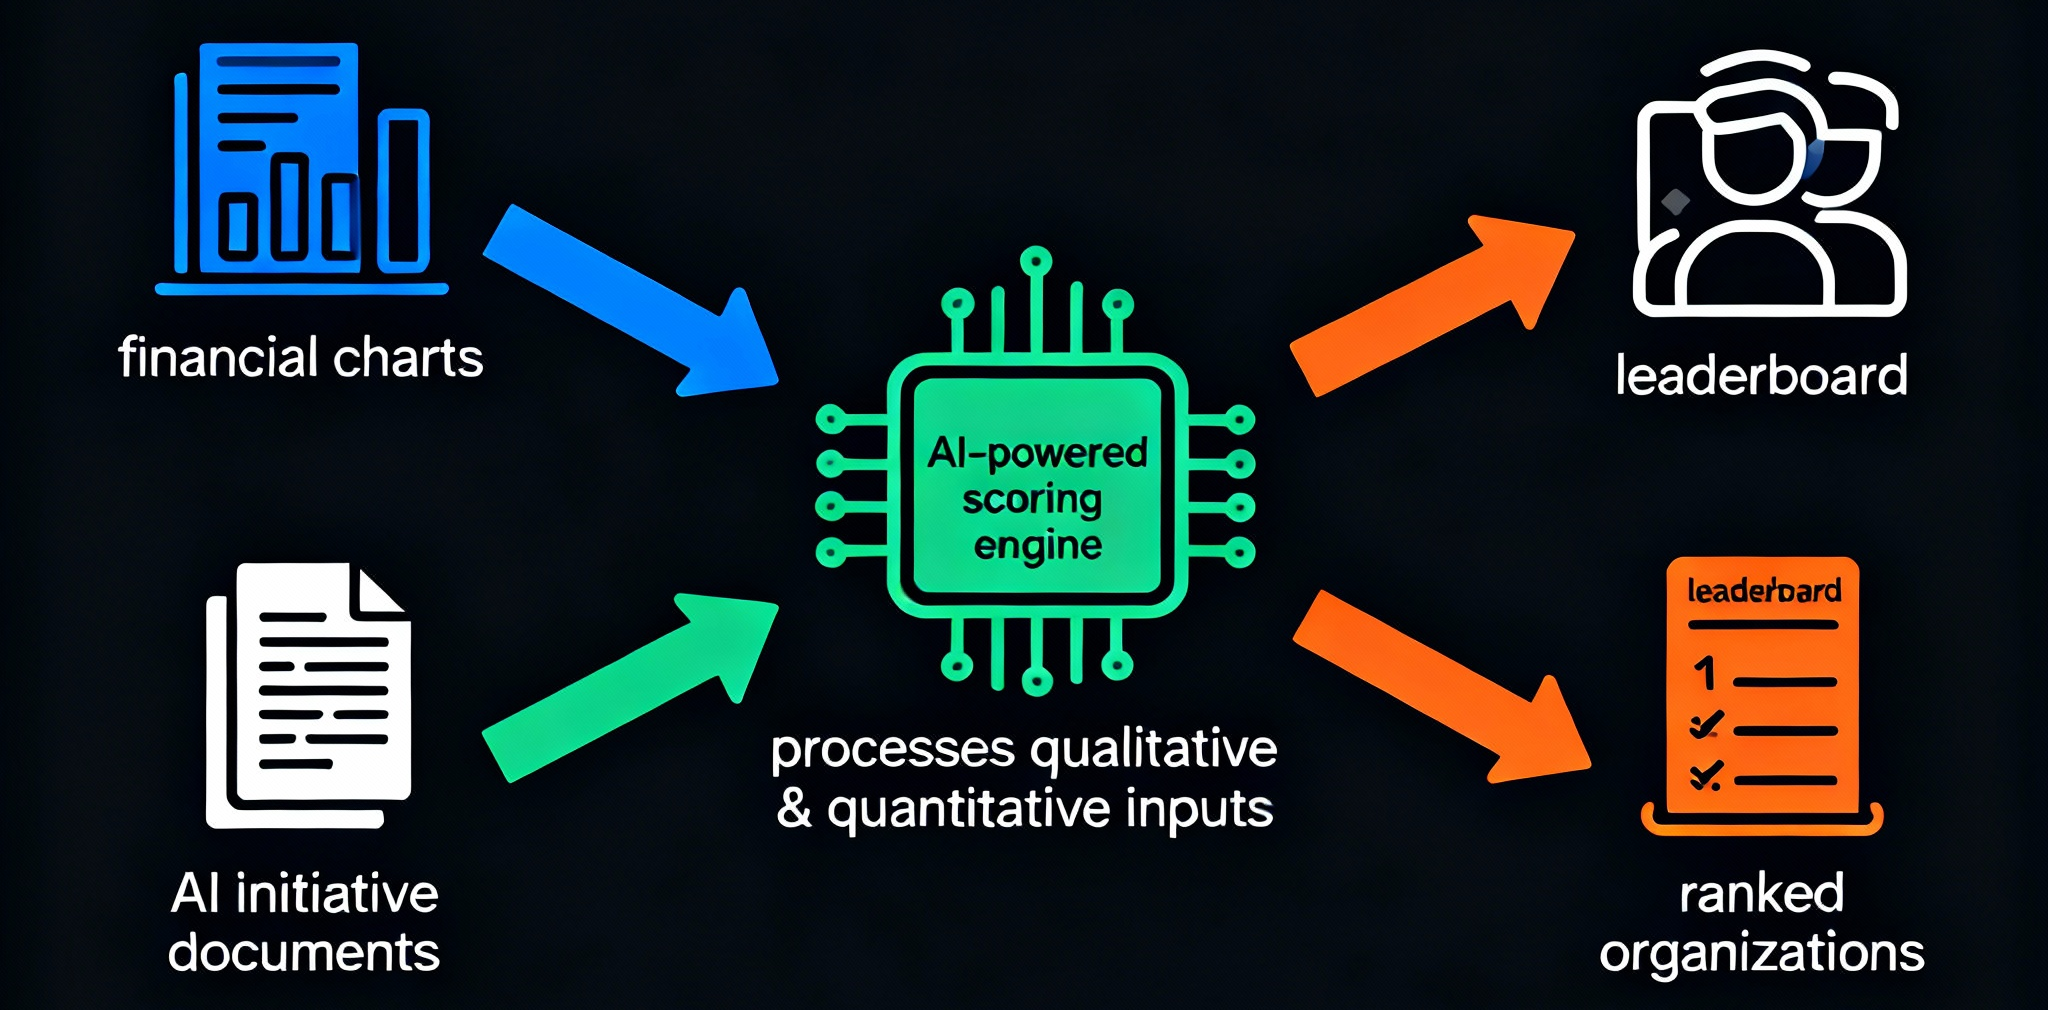

Prompting an LLM to score each company by integrating Quantitative data (stock trend, growth metrics) and Qualitative evidence (PDF insights)

> <font color="red" size=5>**Your Task**</font>
1. Write a system message and a user message that outlines the required data for the prompt.
2. Prompt the LLM to rank and recommend companies for investment based on the provided PDF and stock data to achieve better returns.

In [52]:
# Fetching all the links of the documents
len(vectorstore.get()['documents'])

62

In [53]:
# Write a system message for instructing the LLM for scoring and ranking the companies
system_message = """
You are an expert financial and AI strategy analyst.
Your task is to evaluate and rank companies using a structured, multi-step reasoning process.

Evaluation Framework:
- Financial Performance (Weight: 60%)
  - Revenue growth
  - Profitability
  - Stability and consistency
- AI Innovation & Initiatives (Weight: 40%)
  - Strength of AI investments
  - Real-world impact of AI initiatives
  - Strategic positioning in AI

Instructions:
1. Analyze financial data independently.
2. Analyze AI initiatives independently.
3. Assign a normalized score (0–100) for:
   - Financial Performance
   - AI Innovation
4. Calculate a weighted final score:
   Final Score = (Financial Score × 0.6) + (AI Score × 0.4)
5. Rank companies from highest to lowest final score.

Constraints:
- Use ONLY the provided data.
- Do NOT introduce external knowledge.
- Be objective and consistent across all companies.
- Clearly explain all scoring decisions.

Output Requirements:
- Present results in a clean, readable business report format.
- Include rankings, scores, weighted calculations, and reasoning.
- Keep explanations concise but informative.
"""

In [54]:
# Write a user message for instructing the LLM for scoring and ranking the companies
user_message = f"""
You are given two data sources:
1. Financial Data (structured table)
2. AI Initiatives (unstructured text)

Your task is to evaluate and rank companies using the defined framework.
---
### Step-by-Step Tasks:
Step 1: Extract key financial insights for each company.
Step 2: Extract key AI-related insights for each company.
Step 3: Score each company:
    - Financial Score (0–100)
    - AI Score (0–100)
Step 4: Apply weighting:
    Final Score = (Financial Score × 0.6) + (AI Score × 0.4)
Step 5: Rank all companies from highest to lowest Final Score.
---

### Data Provided:

#### Financial Data:
{df.to_string()}
#### AI Initiatives:
{vectorstore.get()['documents']}
---

### Output Format:

For each company, provide:
Company Name:
- Financial Score:
- AI Score:
- Final Weighted Score:
- Ranking Position:

Financial Analysis:
Brief explanation of the company’s financial performance.

AI Analysis:
Brief explanation of the company’s AI initiatives and innovation strategy.

Overall Assessment:
Short summary explaining why the company received its final ranking.

After evaluating all companies, provide a final ranked summary list from strongest to weakest company.
"""

In [55]:
# Formatting the prompt
formatted_prompt = f"""[INST]{system_message}\n
                {'user'}: {user_message}
                [/INST]"""

In [56]:
# Calling the LLM
recommendation = llm.invoke(formatted_prompt)
recommendation.content

"# Company Evaluation and Ranking Report\n\n## Company Evaluations\n\n### 1. Google (GOOGL)\n- **Financial Score:** 85\n- **AI Score:** 90\n- **Final Weighted Score:** 86.0\n- **Ranking Position:** 1st\n\n**Financial Analysis:**\nGoogle has a strong financial performance with a market cap of approximately $4.8 trillion, a P/E ratio of about 30, and significant revenue growth at $422 billion. The company shows stability through consistent revenue generation.\n\n**AI Analysis:**\nGoogle is at the forefront of AI innovation with initiatives like Gemini, which integrates advanced multimodal capabilities into its products such as Google Search and Workspace. Its commitment to responsible AI development enhances its strategic positioning in the market.\n\n**Overall Assessment:**\nGoogle's combination of robust financial health and cutting-edge AI initiatives positions it as the leader in this evaluation.\n\n---\n\n### 2. Microsoft (MSFT)\n- **Financial Score:** 80\n- **AI Score:** 88\n- **Fi

In [57]:
print(recommendation.content)

# Company Evaluation and Ranking Report

## Company Evaluations

### 1. Google (GOOGL)
- **Financial Score:** 85
- **AI Score:** 90
- **Final Weighted Score:** 86.0
- **Ranking Position:** 1st

**Financial Analysis:**
Google has a strong financial performance with a market cap of approximately $4.8 trillion, a P/E ratio of about 30, and significant revenue growth at $422 billion. The company shows stability through consistent revenue generation.

**AI Analysis:**
Google is at the forefront of AI innovation with initiatives like Gemini, which integrates advanced multimodal capabilities into its products such as Google Search and Workspace. Its commitment to responsible AI development enhances its strategic positioning in the market.

**Overall Assessment:**
Google's combination of robust financial health and cutting-edge AI initiatives positions it as the leader in this evaluation.

---

### 2. Microsoft (MSFT)
- **Financial Score:** 80
- **AI Score:** 88
- **Final Weighted Score:** 83.

#**6. Summary and Future Scope - 4 Marks**

Based on the project, learners are expected to share their observations, key learnings, and insights related to the business use case, including any challenges they encountered. Additionally, they should recommend improvements to the project and suggest further steps for enhancement.

**A. Summary / Your Observations about this Project - 2 Marks**


1.   Hybrid analysis delivers richer investment insight. The DualLens Analytics system demonstrated that combining quantitative financial data (3-year stock trends, market cap, P/E ratio, dividend yield, beta, and total revenue via YFinance) with qualitative AI initiative documents (via a RAG pipeline over company PDFs) produces a more complete investment picture than either data source alone. The weighted scoring model — Financial Performance (60%) + AI Innovation (40%) — provided an objective, reproducible ranking of all five companies: GOOGL, MSFT, IBM, NVDA, and AMZN.
2.   RAG with ChromaDB enabled effective unstructured document retrieval. By splitting company AI strategy PDFs into 1,000-token chunks with 200-token overlap, embedding them using text-embedding-ada-002, and storing them in a ChromaDB vector store, the system could accurately retrieve relevant passages in response to natural-language queries (e.g., "What are the three projects MSFT is working on?"). The LLM-as-judge evaluation using Groundedness and Relevance metrics (scored 1–5) confirmed that the generated answers were both factually grounded in the retrieved context and directly relevant to the questions asked.
3.   AI innovation does not always correlate with financial strength. The two-dimensional scoring revealed a non-trivial gap between companies that lead in AI strategy (e.g., NVDA, MSFT) and those with strong but less AI-forward financials (e.g., IBM). This validated the core premise of the project: financial metrics alone would have ranked companies differently than the combined dual-lens score, reinforcing the business value of integrating qualitative strategic documents into investment analysis.


**B.
Future scope of this Project  - 2 Marks**

1. Real-time social media sentiment analysis. Scrape the latest company news and social media posts (Twitter/X, Reddit, news APIs) and run sentiment analysis on them. Incorporating live public sentiment as a third data dimension would make the rankings more responsive to breaking developments (e.g., product launches, regulatory actions, earnings surprises).
2. Real-time and continuous data pipeline. The current system is a point-in-time snapshot. A future version could integrate live data feeds — earnings call transcripts, SEC filings, and real-time stock prices — so that the financial scores and PDF-based RAG index are automatically updated on a scheduled basis, enabling investors to track ranking changes over time rather than relying on a single static report.
3. Interactive investor dashboard with customizable weights. Build a Streamlit or Gradio front-end that lets users adjust the Financial vs. AI Innovation weighting (currently fixed at 60/40), query the RAG system in natural language, and visualize company scores interactively. We can also incorporate other user customization by allowing the user to define there own strategies and evaluations. This would transform the notebook from a one-off analysis tool into a reusable, self-service investment intelligence platform that can be extended to cover additional sectors and geographies.